# Chapter 21 · Kubernetes: walkthrough

Companion to `notes/21_kubernetes.html` (video 10:18:09 – 10:46:14).

The video deploys a Flask app to **Google Kubernetes Engine**: build an image → push it to the Google registry →
create a cluster → `kubectl create deployment` → `kubectl expose … --type=LoadBalancer` → open the external IP.
That needs a paid cloud cluster, so this notebook does the parts that work offline:

| Part | What happens |
|---|---|
| 1 | the manifests for our Chapter 17 API, validated with **kubeconform** |
| 2 | the video's imperative commands vs the same thing as YAML |
| 3 | apply them to a **simulated cluster** (`toy_k8s.py`): Deployment → ReplicaSet → Pods → Service |
| 4 | **self-healing**: delete a pod, break a container's liveness probe |
| 5 | **load balancing**: where 300 requests actually land, before and after scaling |
| 6 | **rolling update** with `maxUnavailable: 0` → no dropped requests |
| 7 | a **bad release**: the rollout gets stuck, then `kubectl rollout undo` |
| 8 | **autoscaling** (HPA) as load rises and falls |
| 9 | a **node failure**, and what "Pending" means |
| 10 | the real GKE commands to run later, and the clean-up list |

`toy_k8s.py` is a ~300-line imitation of the control loops, not Kubernetes. It exists to make the loops visible;
everything it prints, a real cluster would print in a similar shape.

In [1]:
import shutil, subprocess, sys, json
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
assert (HERE / "toy_k8s.py").exists(), "run this notebook from projects/ch21_kubernetes"
sys.path.insert(0, str(HERE))
import importlib, toy_k8s as k8s
importlib.reload(k8s)
REPORTS = HERE / "reports"; REPORTS.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 100); pd.set_option("display.width", 200)

for tool in ("kubectl", "docker", "minikube", "kind", "gcloud"):
    print(f"{tool:<9}", shutil.which(tool) or "not installed on this machine")

kubectl   not installed on this machine
docker    not installed on this machine
minikube  not installed on this machine
kind      not installed on this machine
gcloud    not installed on this machine


Nothing is installed, and there is no cluster — exactly the situation the instructor warns about
("setting Kubernetes up locally causes lots of issues and takes space, so use the cloud").
So: real manifests + a schema validator + a simulator.

## 1 · The manifests

In [2]:
MANIFESTS = sorted((HERE / "manifests").glob("*.yaml"))
docs = {p.name: yaml.safe_load(p.read_text()) for p in MANIFESTS}
rows = [{"file": n, "kind": d["kind"], "name": d["metadata"]["name"],
         "what it does": {"Namespace": "keeps this app's objects separate",
                          "Deployment": "keeps N identical pods running, and updates them safely",
                          "Service": "one stable address + load balancing across ready pods",
                          "HorizontalPodAutoscaler": "changes the replica count from CPU usage",
                          "PodDisruptionBudget": "keeps a minimum available during node drains"}[d["kind"]]}
        for n, d in docs.items()]
pd.DataFrame(rows)

,file,kind,name,what it does
0,00-namespace.yaml,Namespace,mlops,keeps this app's objects separate
1,10-deployment.yaml,Deployment,yt-sentiment,"keeps N identical pods running, and updates them safely"
2,20-service.yaml,Service,yt-sentiment,one stable address + load balancing across ready pods
3,30-hpa.yaml,HorizontalPodAutoscaler,yt-sentiment,changes the replica count from CPU usage
4,40-pdb.yaml,PodDisruptionBudget,yt-sentiment,keeps a minimum available during node drains


In [3]:
print((HERE / "manifests" / "10-deployment.yaml").read_text())

# The Chapter 17 sentiment API, as a Deployment.
# The video runs `kubectl create deployment …` instead; a file like this is what you keep in git.
apiVersion: apps/v1
kind: Deployment
metadata:
  name: yt-sentiment
  namespace: mlops
  labels: { app: yt-sentiment }
spec:
  replicas: 3                        # the ReplicaSet keeps exactly this many pods alive
  revisionHistoryLimit: 5            # how many old ReplicaSets to keep for `kubectl rollout undo`
  selector:
    matchLabels: { app: yt-sentiment }
  strategy:
    type: RollingUpdate
    rollingUpdate:
      maxSurge: 1                    # at most 1 extra pod during an update
      maxUnavailable: 0              # never drop below `replicas` ready pods → no downtime
  template:
    metadata:
      labels: { app: yt-sentiment }
    spec:
      containers:
        - name: api
          # push the Chapter 17 image here first:
          #   docker build -t <region>-docker.pkg.dev/<project>/ml/yt-sentiment:v1 projects/ch17_youtube_s

In [4]:
# kubeconform checks every manifest against the official Kubernetes JSON schemas (offline once cached).
KUBECONFORM = HERE.parent / "_tools" / "bin" / "kubeconform"
res = subprocess.run([KUBECONFORM, "-summary", "-strict", "-kubernetes-version", "1.31.0",
                      *[str(p) for p in MANIFESTS]], capture_output=True, text=True)
print(res.stdout or res.stderr)

# a deliberate mistake, to show what the validator catches
broken = yaml.safe_load((HERE / "manifests" / "10-deployment.yaml").read_text())
broken["spec"]["replicas"] = "three"                 # must be an integer
broken["spec"]["template"]["spec"]["containers"][0]["ports"][0]["containerPort"] = "8080"
(REPORTS / "broken.yaml").write_text(yaml.safe_dump(broken))
res = subprocess.run([KUBECONFORM, "-strict", str(REPORTS / "broken.yaml")], capture_output=True, text=True)
print(res.stdout or res.stderr)
(REPORTS / "broken.yaml").unlink()

Summary: 5 resources found in 5 files - Valid: 5, Invalid: 0, Errors: 0, Skipped: 0



/Users/hemanthreddy/Desktop/data_science/MLOps/projects/ch21_kubernetes/reports/broken.yaml - Deployment yt-sentiment is invalid: problem validating schema. Check JSON formatting: jsonschema validation failed with 'https://raw.githubusercontent.com/yannh/kubernetes-json-schema/master/master-standalone-strict/deployment-apps-v1.json#' - at '/spec/replicas': got string, want null or integer - at '/spec/template/spec/containers/0/ports/0/containerPort': got string, want integer



Validating manifests in CI catches typos before they reach a cluster, the same way `actionlint` did for workflows in Chapter 18.

## 2 · The video's commands vs the same thing as YAML

In [5]:
compare = pd.DataFrame([
    ("build the image",
     "docker build -t gcr.io/$PROJECT_ID/insurance-app:v1 .",
     "same (the image is built by CI in Chapter 18)"),
    ("push the image",
     "gcloud auth configure-docker gcr.io && docker push gcr.io/$PROJECT_ID/insurance-app:v1",
     "same, but to Artifact Registry: <region>-docker.pkg.dev/<project>/ml/yt-sentiment:v1"),
    ("create the cluster",
     "gcloud container clusters create ml-cluster --num-nodes=1",
     "same (a cluster is infrastructure, not app config)"),
    ("run the app",
     "kubectl create deployment insurance-app --image=…:v1",
     "kubectl apply -f manifests/10-deployment.yaml"),
    ("expose it",
     "kubectl expose deployment insurance-app --type=LoadBalancer --port 80 --target-port 8080",
     "kubectl apply -f manifests/20-service.yaml"),
    ("scale it",
     "kubectl scale deployment insurance-app --replicas=3",
     "edit `replicas:` (or let the HPA do it) → kubectl apply"),
    ("update the app",
     "kubectl set image deployment/insurance-app …:v2",
     "edit `image:` → kubectl apply  (git shows who changed what, and `rollout undo` still works)"),
], columns=["step", "video (imperative)", "ours (declarative files in git)"])
compare

,step,video (imperative),ours (declarative files in git)
0,build the image,docker build -t gcr.io/$PROJECT_ID/insurance-app:v1 .,same (the image is built by CI in Chapter 18)
1,push the image,gcloud auth configure-docker gcr.io && docker push gcr.io/$PROJECT_ID/insurance-app:v1,"same, but to Artifact Registry: <region>-docker.pkg.dev/<project>/ml/yt-sentiment:v1"
2,create the cluster,gcloud container clusters create ml-cluster --num-nodes=1,"same (a cluster is infrastructure, not app config)"
3,run the app,kubectl create deployment insurance-app --image=…:v1,kubectl apply -f manifests/10-deployment.yaml
4,expose it,kubectl expose deployment insurance-app --type=LoadBalancer --port 80 --target-port 8080,kubectl apply -f manifests/20-service.yaml
5,scale it,kubectl scale deployment insurance-app --replicas=3,edit `replicas:` (or let the HPA do it) → kubectl apply
6,update the app,kubectl set image deployment/insurance-app …:v2,"edit `image:` → kubectl apply (git shows who changed what, and `rollout undo` still works)"


Both create the same objects. The difference is that the imperative commands live only in your shell history,
while the files can be reviewed, versioned and re-applied. That's the idea behind **GitOps**: the repo is the
desired state, and a controller keeps the cluster matching it.

## 3 · Apply the manifests to a simulated cluster
Two nodes with 1.5 CPU each. Every pod requests 250 mCPU, so each node holds 6 pods.

In [6]:
cluster = k8s.Cluster(nodes=("node-1", "node-2"), node_cpu=1.5)   # 1.5 cores each → 6 pods of 250m per node
cluster.apply(docs["10-deployment.yaml"]).apply(docs["20-service.yaml"])
cluster.settle()
print(cluster.get_deployments(), "\n")
print(cluster.get_replicasets(), "\n")
print(cluster.get_pods())

NAME            READY   UP-TO-DATE  AVAILABLE  REVISION IMAGE
yt-sentiment    3/3     3           3          1        yt-sentiment:v1 

NAME                      DESIRED  CURRENT  READY  REVISION IMAGE
yt-sentiment-0001         3        3        3      1        v1 

NAME                      READY  STATUS      RESTARTS  NODE     IMAGE       AGE
yt-sentiment-0001-0002    1/1    Running     0         node-1   v1          25s
yt-sentiment-0001-0003    1/1    Running     0         node-2   v1          25s
yt-sentiment-0001-0004    1/1    Running     0         node-1   v1          25s


In [7]:
print("\n".join(cluster.events))

   0s  deployment created yt-sentiment (replicas=3, image=yt-sentiment:v1)
   0s  service    created yt-sentiment (LoadBalancer, external IP 34.118.0.42)
   5s  replicaset created yt-sentiment-0001 for revision 1
   5s  replicaset yt-sentiment-0001 created pod yt-sentiment-0001-0002 (have 1/3)
   5s  replicaset yt-sentiment-0001 created pod yt-sentiment-0001-0003 (have 2/3)
   5s  replicaset yt-sentiment-0001 created pod yt-sentiment-0001-0004 (have 3/3)
   5s  scheduler  assigned yt-sentiment-0001-0002 → node-1
   5s  scheduler  assigned yt-sentiment-0001-0003 → node-2
   5s  scheduler  assigned yt-sentiment-0001-0004 → node-1
  15s  kubelet    yt-sentiment-0001-0002 is Ready
  15s  kubelet    yt-sentiment-0001-0003 is Ready
  15s  kubelet    yt-sentiment-0001-0004 is Ready


The chain is: **you edit a Deployment → its controller creates a ReplicaSet → that keeps N Pods → the scheduler
picks nodes → each kubelet starts the container and runs the probes → ready pods join the Service.**
Nobody told Kubernetes *how*; it keeps comparing the real state with the desired state.

## 4 · Self-healing

In [8]:
victim = sorted(cluster.pods)[0]
print(f"$ kubectl delete pod {victim}")
cluster.delete_pod(victim)
cluster.settle()
print(cluster.get_pods())

$ kubectl delete pod yt-sentiment-0001-0002
NAME                      READY  STATUS      RESTARTS  NODE     IMAGE       AGE
yt-sentiment-0001-0003    1/1    Running     0         node-2   v1          55s
yt-sentiment-0001-0004    1/1    Running     0         node-1   v1          55s
yt-sentiment-0001-0005    1/1    Running     0         node-1   v1          25s


In [9]:
# now a container that stops answering its liveness probe (a hung worker, a deadlock…)
sick = sorted(cluster.pods)[1]
cluster.break_container(sick)
cluster.settle()
print(cluster.get_pods())
print("\n".join(e for e in cluster.events[-6:]))

NAME                      READY  STATUS      RESTARTS  NODE     IMAGE       AGE
yt-sentiment-0001-0003    1/1    Running     0         node-2   v1          85s
yt-sentiment-0001-0004    1/1    Running     1         node-1   v1          85s
yt-sentiment-0001-0005    1/1    Running     0         node-1   v1          55s
  35s  replicaset yt-sentiment-0001 created pod yt-sentiment-0001-0005 (have 3/3)
  35s  scheduler  assigned yt-sentiment-0001-0005 → node-1
  45s  kubelet    yt-sentiment-0001-0005 is Ready
  60s  probe      liveness probe failing on yt-sentiment-0001-0004
  65s  kubelet    restarted yt-sentiment-0001-0004 (restart count 1)
  75s  kubelet    yt-sentiment-0001-0004 is Ready


This is the "self-healing" from the video's feature list: a deleted pod is replaced (the ReplicaSet counts),
and a container failing its **liveness** probe is restarted (the kubelet acts), with the restart counter going up.
A pod failing its **readiness** probe isn't restarted; it's just taken out of the Service until it recovers.

## 5 · Load balancing: where do the requests go?

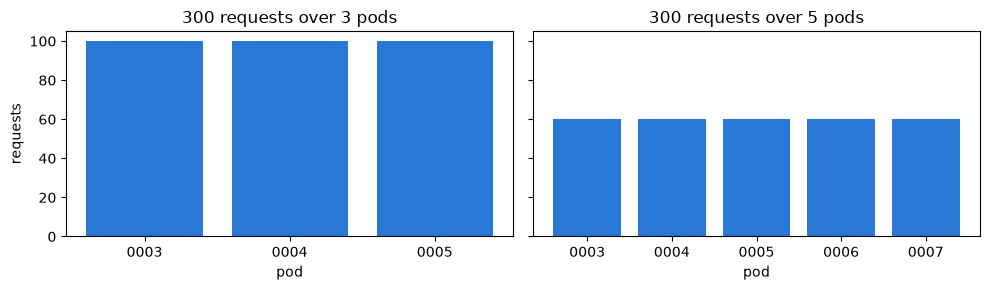

yt-sentiment-0001-0003    100
yt-sentiment-0001-0004    100
yt-sentiment-0001-0005    100

yt-sentiment-0001-0003    60
yt-sentiment-0001-0004    60
yt-sentiment-0001-0005    60
yt-sentiment-0001-0006    60
yt-sentiment-0001-0007    60


In [10]:
hits, failed = cluster.route("yt-sentiment", 300)
before = pd.Series(hits, name="3 replicas")
cluster.scale("yt-sentiment", 5); cluster.settle()
hits5, _ = cluster.route("yt-sentiment", 300)
after = pd.Series(hits5, name="5 replicas")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, s in zip(axes, (before, after)):
    ax.bar(range(len(s)), s.values, color="#2a78d6")
    ax.set_title(f"300 requests over {len(s)} pods"); ax.set_xticks(range(len(s)))
    ax.set_xticklabels([n.split("-")[-1] for n in s.index]); ax.set_xlabel("pod")
axes[0].set_ylabel("requests")
plt.tight_layout(); plt.savefig(REPORTS / "ch21_routing.png", dpi=110); plt.show()
print(before.to_string(), "\n\n", after.to_string(), sep="")

The Service spreads connections across **ready** pods only. Adding replicas immediately lowers each pod's share:
that's the load balancing the instructor describes, and it's why "scale up" is just a number in the Deployment.

## 6 · A rolling update with no downtime
`maxSurge: 1, maxUnavailable: 0` means: never fewer than `replicas` ready pods, at most one extra during the update.

In [11]:
cluster.scale("yt-sentiment", 3); cluster.settle()
start = len(cluster.history)
cluster.set_image("yt-sentiment", "REGION-docker.pkg.dev/PROJECT_ID/ml/yt-sentiment:v2")
cluster.settle()
hist = pd.DataFrame(cluster.history[start:])
print("rollout complete:", cluster.rollout_complete("yt-sentiment"))
print(cluster.get_replicasets())
print("\nlowest number of ready pods during the update:", hist["ready"].min(), "(replicas = 3 → no downtime)")

rollout complete: True
NAME                      DESIRED  CURRENT  READY  REVISION IMAGE
yt-sentiment-0001         0        0        0      1        v1
yt-sentiment-0008         3        3        3      2        v2

lowest number of ready pods during the update: 3 (replicas = 3 → no downtime)


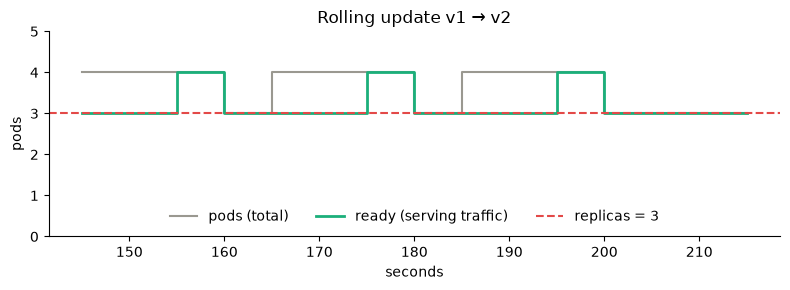

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.step(hist["t"], hist["pods"], where="post", label="pods (total)", color="#9a9890")
ax.step(hist["t"], hist["ready"], where="post", label="ready (serving traffic)", color="#1baf7a", linewidth=2)
ax.axhline(3, ls="--", color="#e34948", label="replicas = 3")
ax.set_xlabel("seconds"); ax.set_ylabel("pods"); ax.set_ylim(0, 5)
ax.legend(frameon=False, ncol=3, loc="lower center"); ax.set_title("Rolling update v1 → v2")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(REPORTS / "ch21_rollout.png", dpi=110); plt.show()

The total climbs to 4 (the surge pod), and ready never drops below 3. Compare with Chapter 18's deployment script,
which stops the old container before starting the new one, so every request fails for a few seconds.

## 7 · A bad release, and `kubectl rollout undo`
The new image starts but never passes its readiness probe (a missing model file, a bad config…).

In [13]:
start = len(cluster.history)
cluster.set_image("yt-sentiment", "REGION-docker.pkg.dev/PROJECT_ID/ml/yt-sentiment:v3-bad")
cluster.settle(max_ticks=14)
print("rollout complete:", cluster.rollout_complete("yt-sentiment"),
      " ← `kubectl rollout status` would wait here and fail with 'progress deadline exceeded'\n")
print(cluster.get_pods(), "\n")
hist_bad = pd.DataFrame(cluster.history[start:])
print("ready pods during the failed rollout:", sorted(hist_bad["ready"].unique()),
      "→ users never noticed; the old version kept serving")

rollout complete: False  ← `kubectl rollout status` would wait here and fail with 'progress deadline exceeded'

NAME                      READY  STATUS      RESTARTS  NODE     IMAGE       AGE
yt-sentiment-0008-0009    1/1    Running     0         node-2   v2          90s
yt-sentiment-0008-000a    1/1    Running     0         node-1   v2          70s
yt-sentiment-0008-000b    1/1    Running     0         node-2   v2          50s
yt-sentiment-000c-000d    0/1    Running     0         node-1   v3-bad      15s 

ready pods during the failed rollout: [np.int64(3)] → users never noticed; the old version kept serving


In [14]:
print("$ kubectl rollout undo deployment/yt-sentiment")
cluster.rollout_undo("yt-sentiment")
cluster.settle()
print(cluster.get_replicasets(), "\n")
print(cluster.get_pods())

$ kubectl rollout undo deployment/yt-sentiment
NAME                      DESIRED  CURRENT  READY  REVISION IMAGE
yt-sentiment-0001         0        0        0      1        v1
yt-sentiment-0008         3        3        3      2        v2
yt-sentiment-000c         0        0        0      3        v3-bad 

NAME                      READY  STATUS      RESTARTS  NODE     IMAGE       AGE
yt-sentiment-0008-0009    1/1    Running     0         node-2   v2         110s
yt-sentiment-0008-000a    1/1    Running     0         node-1   v2          90s
yt-sentiment-0008-000b    1/1    Running     0         node-2   v2          70s


Because `maxUnavailable: 0`, the broken version never took traffic. That's the difference between
"deploy and hope" and a platform that checks readiness before shifting load.

## 8 · Autoscaling (HPA) as load changes
`averageUtilization: 60` on a 250 mCPU request means: keep each pod at about 150 mCPU.

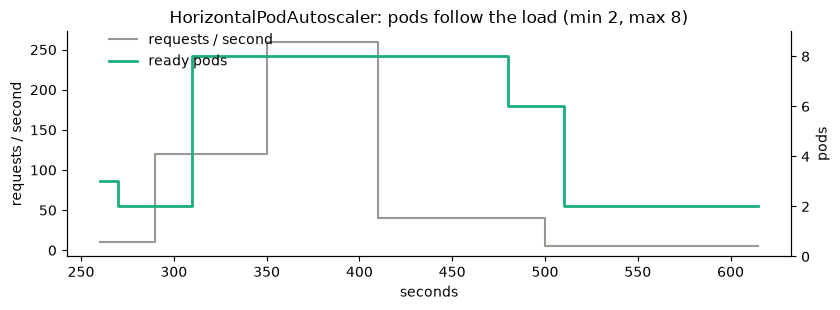

 255s  hpa        created yt-sentiment (min=2, max=8, cpu target=60%)
 270s  hpa        cpu 27% < target for a while → scale down to 2
 300s  hpa        cpu 480% of request > target 60% → scale up to 8
 420s  hpa        cpu 40% < target, but still inside the stabilisation window (3 check(s) to go)
 435s  hpa        cpu 40% < target, but still inside the stabilisation window (2 check(s) to go)
 450s  hpa        cpu 40% < target, but still inside the stabilisation window (1 check(s) to go)
 465s  hpa        cpu 40% < target, but still inside the stabilisation window (0 check(s) to go)
 480s  hpa        cpu 40% < target for a while → scale down to 6
 510s  hpa        cpu 7% < target for a while → scale down to 2


In [15]:
cluster.apply(docs["30-hpa.yaml"])
start = len(cluster.history)
for rps, ticks in [(10, 6), (120, 12), (260, 12), (40, 18), (5, 24)]:   # a traffic spike and a quiet evening
    cluster.load_rps = rps
    cluster.tick(ticks, quiet=True)
h = pd.DataFrame(cluster.history[start:])

fig, ax1 = plt.subplots(figsize=(8.5, 3.2))
ax1.step(h["t"], h["rps"], where="post", color="#9a9890", label="requests / second")
ax1.set_ylabel("requests / second"); ax1.set_xlabel("seconds")
ax2 = ax1.twinx()
ax2.step(h["t"], h["ready"], where="post", color="#1baf7a", linewidth=2, label="ready pods")
ax2.set_ylabel("pods"); ax2.set_ylim(0, 9)
ax1.set_title("HorizontalPodAutoscaler: pods follow the load (min 2, max 8)")
for a in (ax1, ax2):
    for s in ("top",): a.spines[s].set_visible(False)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92), frameon=False)
plt.tight_layout(); plt.savefig(REPORTS / "ch21_hpa.png", dpi=110); plt.show()
print("\n".join(e for e in cluster.events if " hpa " in e)[-900:])

Two things the video's setup would miss:
* the HPA needs **CPU requests** in the Deployment, otherwise there's no percentage to compare against
* scaling **up** is fast, scaling **down** waits out a stabilisation window (5 minutes by default) so a brief dip doesn't kill pods

Pods can only scale up while the nodes have room. When they don't, new pods sit **Pending** and a *Cluster Autoscaler*
(or Autopilot) has to add nodes: the next cell shows the Pending state.

## 9 · A node failure

In [16]:
cluster.load_rps = 240
cluster.tick(9, quiet=True)                 # scale up again so the failure hurts
ready = len(cluster.ready_pods("yt-sentiment"))
capacity = int(sum(n.cpu for n in cluster.nodes.values() if n.ready) / 0.25)
print(f"before: {ready} ready pods across 2 nodes (room for {capacity} pods in total)")
cluster.fail_node("node-1")
cluster.settle()
print(cluster.get_pods())
capacity = int(sum(n.cpu for n in cluster.nodes.values() if n.ready) / 0.25)
pending = [p for p in cluster.pods.values() if p.node is None]
print(f"\none node left → room for {capacity} pods, {len(pending)} pod(s) stuck Pending")
print("\n".join(e for e in cluster.events[-4:]))

before: 8 ready pods across 2 nodes (room for 12 pods in total)
NAME                      READY  STATUS      RESTARTS  NODE     IMAGE       AGE
yt-sentiment-0008-0013    1/1    Running     0         node-2   v2         390s
yt-sentiment-0008-0015    1/1    Running     0         node-2   v2          60s
yt-sentiment-0008-0017    1/1    Running     0         node-2   v2          60s
yt-sentiment-0008-0019    1/1    Running     0         node-2   v2          60s
yt-sentiment-0008-001a    1/1    Running     0         node-2   v2          25s
yt-sentiment-0008-001b    1/1    Running     0         node-2   v2          25s
yt-sentiment-0008-001c    0/1    Pending     0         <none>   v2          25s
yt-sentiment-0008-001d    0/1    Pending     0         <none>   v2          25s

one node left → room for 6 pods, 2 pod(s) stuck Pending
 685s  scheduler  yt-sentiment-0008-001c stays Pending: no node has 0.25 free CPU
 685s  scheduler  yt-sentiment-0008-001d stays Pending: no node has 0.25 free

The pods on the lost node are gone, the ReplicaSet notices, and the scheduler puts replacements on the
remaining node until it runs out of CPU. The leftovers stay **Pending**: Kubernetes is telling you
"I can't place these — add capacity."

## 10 · The real thing: GKE commands, cost and clean-up

In [17]:
print(r'''
# 1 · build and push (Artifact Registry; gcr.io Container Registry is being shut down)
gcloud auth configure-docker REGION-docker.pkg.dev
docker build --platform linux/amd64 -t REGION-docker.pkg.dev/$PROJECT_ID/ml/yt-sentiment:v1 .
docker push REGION-docker.pkg.dev/$PROJECT_ID/ml/yt-sentiment:v1

# 2 · a cluster (Autopilot: Google manages the nodes and you pay per pod)
gcloud container clusters create-auto ml-cluster --region=REGION
gcloud container clusters get-credentials ml-cluster --region=REGION   # writes ~/.kube/config

# 3 · deploy exactly what is in git
kubectl apply -f manifests/                       # namespace, deployment, service, hpa, pdb
kubectl -n mlops rollout status deployment/yt-sentiment
kubectl -n mlops get pods -o wide
kubectl -n mlops get service yt-sentiment         # EXTERNAL-IP → http://<ip>/

# 4 · day-to-day
kubectl -n mlops logs -f deployment/yt-sentiment
kubectl -n mlops describe pod <name>              # first stop when a pod won't start
kubectl -n mlops set image deployment/yt-sentiment api=...:v2
kubectl -n mlops rollout undo deployment/yt-sentiment
kubectl -n mlops port-forward svc/yt-sentiment 8080:80   # test without a public IP

# 5 · delete everything when you're done
kubectl delete -f manifests/
gcloud container clusters delete ml-cluster --region=REGION
gcloud artifacts docker images delete REGION-docker.pkg.dev/$PROJECT_ID/ml/yt-sentiment --delete-tags
''')


# 1 · build and push (Artifact Registry; gcr.io Container Registry is being shut down)
gcloud auth configure-docker REGION-docker.pkg.dev
docker build --platform linux/amd64 -t REGION-docker.pkg.dev/$PROJECT_ID/ml/yt-sentiment:v1 .
docker push REGION-docker.pkg.dev/$PROJECT_ID/ml/yt-sentiment:v1

# 2 · a cluster (Autopilot: Google manages the nodes and you pay per pod)
gcloud container clusters create-auto ml-cluster --region=REGION
gcloud container clusters get-credentials ml-cluster --region=REGION   # writes ~/.kube/config

# 3 · deploy exactly what is in git
kubectl apply -f manifests/                       # namespace, deployment, service, hpa, pdb
kubectl -n mlops rollout status deployment/yt-sentiment
kubectl -n mlops get pods -o wide
kubectl -n mlops get service yt-sentiment         # EXTERNAL-IP → http://<ip>/

# 4 · day-to-day
kubectl -n mlops logs -f deployment/yt-sentiment
kubectl -n mlops describe pod <name>              # first stop when a pod won't start
kubectl -n mlop

In [18]:
cost = pd.DataFrame([
    ("GKE control plane", "about $0.10 per hour per cluster (one zonal cluster per billing account is free)", "delete the cluster"),
    ("Nodes (Standard)", "the VMs you asked for, whether or not pods use them", "delete the cluster / node pool"),
    ("Autopilot", "billed per pod CPU+memory request, so requests are money", "delete the workloads"),
    ("LoadBalancer Service", "a cloud load balancer, charged per hour + traffic", "delete the Service"),
    ("Artifact Registry", "per GB-month of stored images", "delete the images"),
    ("Persistent disks", "kept after the cluster is gone if made by PVCs", "delete leftover disks"),
], columns=["what costs money", "how", "clean-up"])
cost

,what costs money,how,clean-up
0,GKE control plane,about $0.10 per hour per cluster (one zonal cluster per billing account is free),delete the cluster
1,Nodes (Standard),"the VMs you asked for, whether or not pods use them",delete the cluster / node pool
2,Autopilot,"billed per pod CPU+memory request, so requests are money",delete the workloads
3,LoadBalancer Service,"a cloud load balancer, charged per hour + traffic",delete the Service
4,Artifact Registry,per GB-month of stored images,delete the images
5,Persistent disks,kept after the cluster is gone if made by PVCs,delete leftover disks


The video deletes the cluster and the image at the end, and that's the right habit: a forgotten cluster
quietly bills you every hour.

**Next:** the after-course to-do list has a free way to practise this for real — `minikube` (or `kind`) on your Mac,
where `kubectl apply -f manifests/` works exactly as above, with `minikube tunnel` standing in for the cloud load balancer.